In [17]:
   from google.colab import drive
   drive.mount('/content/drive')

   !cp "/content/drive/MyDrive/BanglaLekha-Isolated.zip" /content/data.zip
   !unzip -l /content/data.zip | head -30

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/data.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2017-02-24 17:13   BanglaLekha-Isolated/
    60103  2017-02-24 16:16   BanglaLekha-Isolated/Form-based Marking.xlsx
        0  2017-02-24 16:29   BanglaLekha-Isolated/Images/
        0  2017-02-24 11:11   BanglaLekha-Isolated/Images/1/
     1142  2016-12-29 02:04   BanglaLekha-Isolated/Images/1/01_0001_0_08_0916_1990_1.png
     1801  2016-12-29 02:03   BanglaLekha-Isolated/Images/1/01_0001_0_11_0916_1913_1.png
     1361  2016-12-29 02:02   BanglaLekha-Isolated/Images/1/01_0001_0_11_0916_1917_1.png
     1097  2016-12-29 02:02   BanglaLekha-Isolated/Images/1/01_0001_0_11_0916_1918_1.png
     1371  2016-12-29 01:59   BanglaLekha-Isolated/Images/1/01_0001_0_11_0916_1919_1.png
     1435  2016-12-29 01:59   BanglaLekha-Isolated/Images/1/01_0001_0_11_0916_192

In [18]:
   !unzip -q /content/data.zip -d /content/BanglaLekha

replace /content/BanglaLekha/BanglaLekha-Isolated/Form-based Marking.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


[1, 2, 3, 4, 5] ... 84 folders


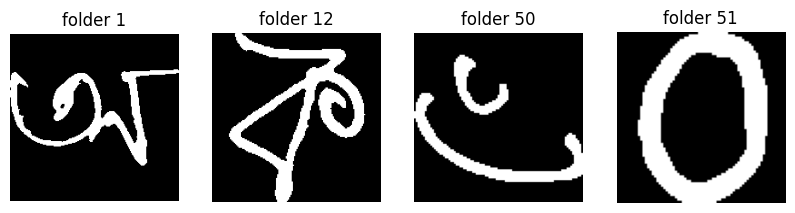

In [19]:
import pathlib, matplotlib.pyplot as plt
from PIL import Image
root = pathlib.Path("/content/BanglaLekha/BanglaLekha-Isolated/Images")
print(sorted(int(p.name) for p in root.iterdir())[:5], "...", len(list(root.iterdir())), "folders")

plt.figure(figsize=(10,2.5))
for k, f in enumerate(["1", "12", "50", "51"]):
    if (root/f).exists():
        img = Image.open(next((root/f).glob("*.png")))
        plt.subplot(1,4,k+1); plt.imshow(img, cmap="gray"); plt.axis("off"); plt.title(f"folder {f}")
plt.show()

In [20]:
import pathlib

DATA_DIR = pathlib.Path("/content/BanglaLekha/BanglaLekha-Isolated/Images")
MAX_PER_CLASS = 800
SELECTED = [str(i) for i in range(1, 51)]
CACHE = "/content/drive/MyDrive/bangla_subset_96.npz"
IMG = 96

In [21]:
import os, pathlib, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
IMG = 64
print(tf.__version__, tf.config.list_physical_devices("GPU"))

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
# ---------- Block 3: Load a balanced subset and cache it ----------
DATA_DIR = pathlib.Path("/content/BanglaLekha/BanglaLekha-Isolated/Images")
MAX_PER_CLASS = 500
SELECTED = [str(i) for i in range(1, 51)]    # folders 1-50 = basic characters
CACHE = "/content/drive/MyDrive/bangla_subset.npz"

def folder_key(s):
    return (0, int(s)) if s.isdigit() else (1, s)

if os.path.exists(CACHE):
    d = np.load(CACHE, allow_pickle=True)
    X, y, class_names = d["X"], d["y"], list(d["classes"])
    print("Loaded from cache")
else:
    folders = [f.name for f in DATA_DIR.iterdir() if f.is_dir()]
    if SELECTED is not None:
        folders = [f for f in folders if f in SELECTED]
    class_names = sorted(folders, key=folder_key)

    X, y = [], []
    for ci, c in enumerate(class_names):
        files = [p for p in (DATA_DIR / c).iterdir()
                 if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}]
        random.shuffle(files)
        for p in files[:MAX_PER_CLASS]:
            img = Image.open(p).convert("L").resize((IMG, IMG), Image.BILINEAR)
            X.append(np.array(img, dtype=np.uint8))
            y.append(ci)
        print(f"\r{ci+1}/{len(class_names)} classes loaded", end="")

    X = np.array(X)[..., None]
    y = np.array(y)
    np.savez_compressed(CACHE, X=X, y=y, classes=np.array(class_names))
    print("\nSaved cache to Drive")

NUM_CLASSES = len(class_names)
print("X:", X.shape, "| classes:", NUM_CLASSES)

Loaded from cache
X: (25000, 64, 64, 1) | classes: 50


In [23]:
print(class_names[:5], "...", class_names[-5:])

[np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')] ... [np.str_('46'), np.str_('47'), np.str_('48'), np.str_('49'), np.str_('50')]


In [24]:
# ---------- Block 4: Stratified split (70/15/15) ----------
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(X_train.shape, X_val.shape, X_test.shape)

(17500, 64, 64, 1) (3750, 64, 64, 1) (3750, 64, 64, 1)


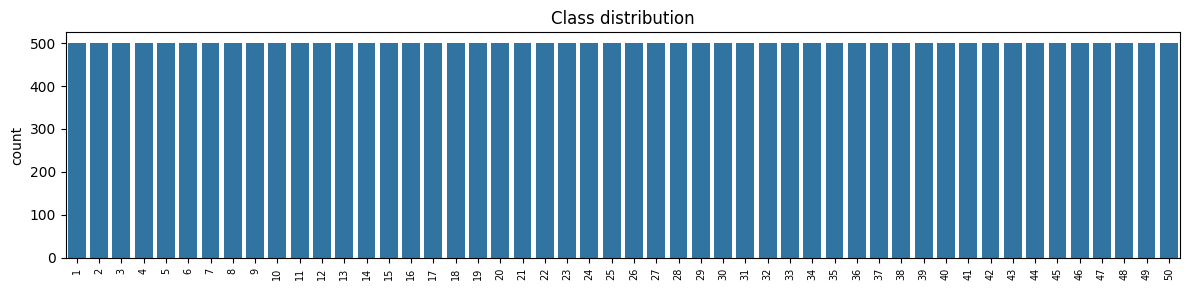

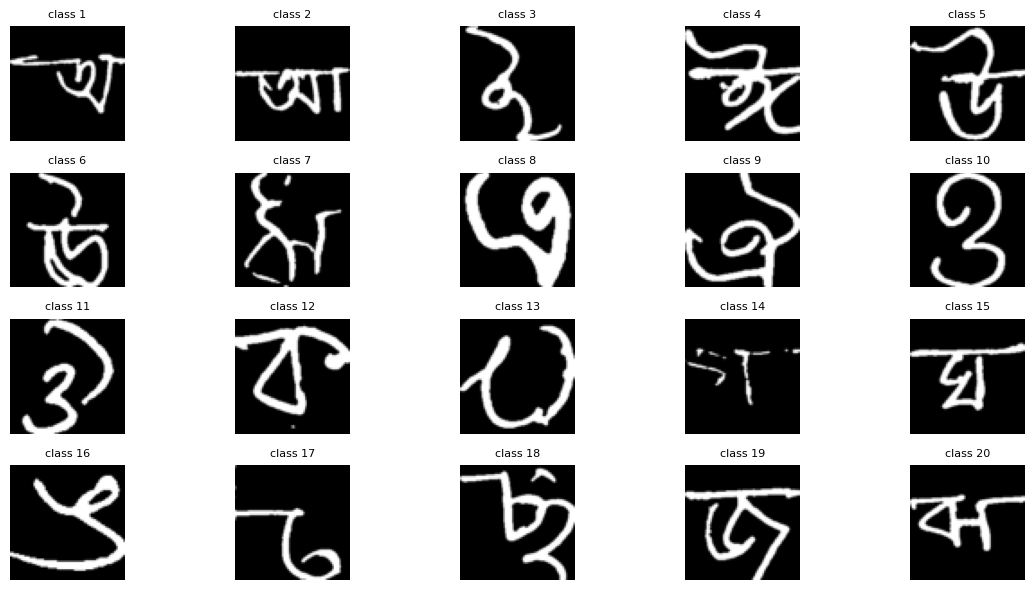

Pixel mean: 44.4 | std: 90.2


In [25]:
# ---------- Block 5: Exploratory data analysis ----------
# Class balance
plt.figure(figsize=(12,3))
sns.countplot(x=[class_names[i] for i in y], order=class_names)
plt.xticks(rotation=90, fontsize=7); plt.title("Class distribution")
plt.tight_layout(); plt.show()

# Sample images (one per class, first 20 classes)
plt.figure(figsize=(12,6))
for k in range(min(20, NUM_CLASSES)):
    idx = np.where(y == k)[0][0]
    plt.subplot(4,5,k+1); plt.imshow(X[idx].squeeze(), cmap="gray"); plt.axis("off")
    plt.title(f"class {class_names[k]}", fontsize=8)
plt.tight_layout(); plt.show()

# Pixel statistics
print("Pixel mean:", X.mean().round(1), "| std:", X.std().round(1))

In [26]:
from tensorflow.keras import layers, models, regularizers

def build_model(input_shape=(96, 96, 1), num_classes=50):
    model = models.Sequential()

    # Data Augmentation (No flips, per project decisions)
    model.add(layers.RandomRotation(0.1, input_shape=input_shape))
    model.add(layers.RandomTranslation(0.1, 0.1))
    model.add(layers.RandomZoom(0.1))

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 4 (New)
    model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Dense Classifier
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model(input_shape=(IMG, IMG, 1), num_classes=50)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_2               │ (None, 64, 64, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_2            │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │        25,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,513,074 (9.59 MB)

 Trainable params: 2,512,114 (9.58 MB)

 Non-trainable params: 960 (3.75 KB)

In [27]:
# ---------- Block 7: Training ----------
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.4, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint("/content/drive/MyDrive/bangla_best.keras",
                                    monitor="val_accuracy", save_best_only=True),
]
hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=40, batch_size=128, callbacks=callbacks)

Epoch 1/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.1495 - loss: 4.2894 - val_accuracy: 0.3485 - val_loss: 2.9140 - learning_rate: 0.0010
Epoch 2/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.3510 - loss: 2.9214 - val_accuracy: 0.5819 - val_loss: 1.9312 - learning_rate: 0.0010
Epoch 3/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.4998 - loss: 2.1936 - val_accuracy: 0.6168 - val_loss: 1.6811 - learning_rate: 0.0010
Epoch 4/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6001 - loss: 1.7851 - val_accuracy: 0.7731 - val_loss: 1.1734 - learning_rate: 0.0010
Epoch 5/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6570 - loss: 1.5799 - val_accuracy: 0.7915 - val_loss: 1.0859 - learning_rate: 0.0010
Epoch 6/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.6946 - loss: 1.4518 - val_accuracy: 0.8051 - val_loss: 1.0371 - learning_rate: 0.0010
Epoch 7/40
137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.7295 - loss: 

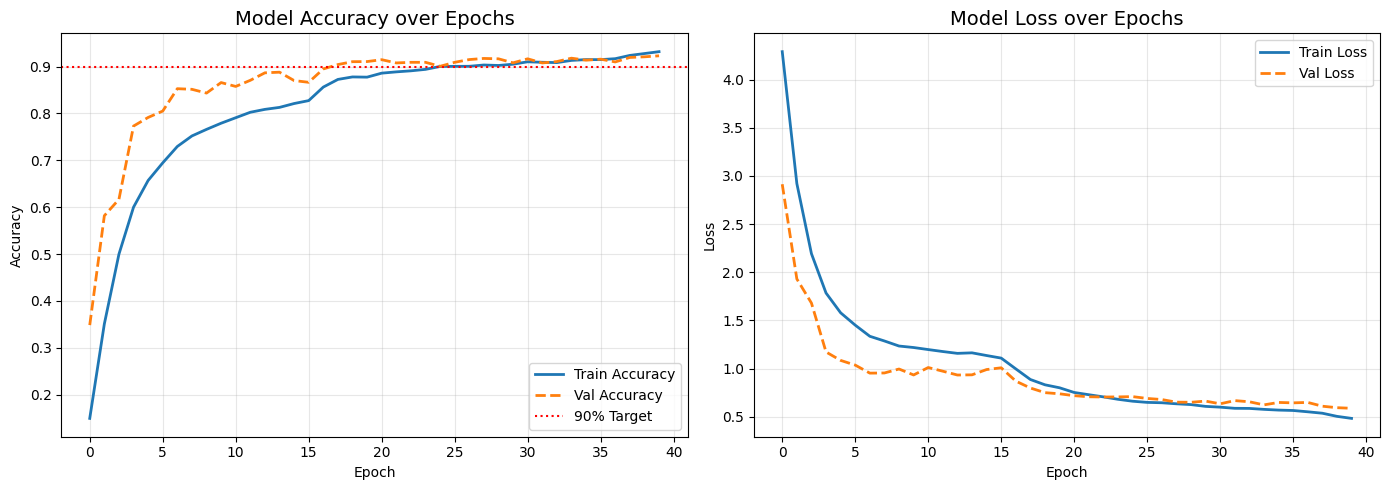

In [29]:
import matplotlib.pyplot as plt

# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(hist.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(hist.history['val_accuracy'], label='Val Accuracy', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(y=0.90, color='r', linestyle=':', label='90% Target')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss curve
axes[1].plot(hist.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(hist.history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9160 - loss: 0.5870

Final Test Loss: 0.5870
Final Test Accuracy: 91.60%

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.9351    0.9600    0.9474        75
           1     1.0000    0.9467    0.9726        75
           2     0.9254    0.8267    0.8732        75
           3     0.9589    0.9333    0.9459        75
           4     0.8400    0.8400    0.8400        75
           5     0.9306    0.8933    0.9116        75
           6     0.9559    0.8667    0.9091        75
           7     0.9211    0.9333    0.9272        75
           8     0.8765    0.9467    0.9103        75
           9     0.9605    0.9733    0.9669        75
          10     0.9857    0.9200    0.9517        75
          11     0.9342    0.9467    0.9404        75
          12     0.8955    0.8000    0.8451        75
          13     0.9605    0.9733    0.9669       

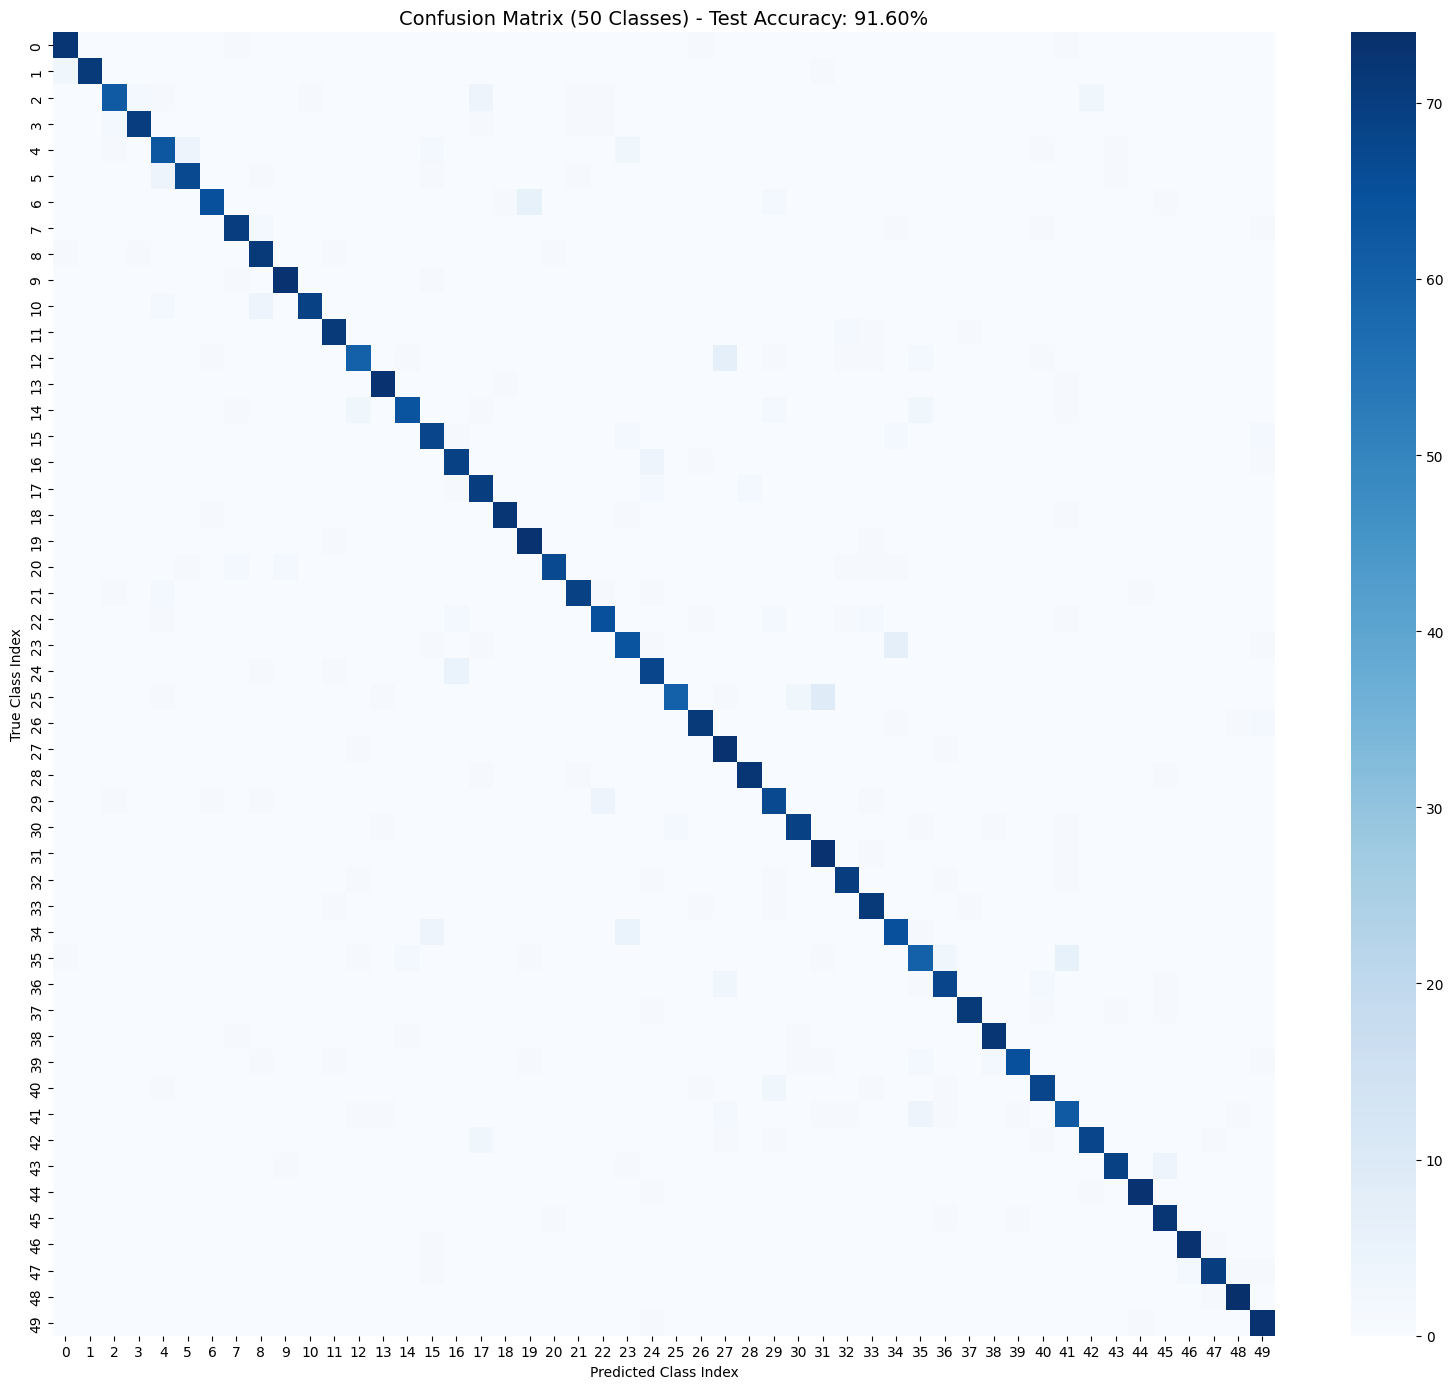

In [30]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

# 2. Generate predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Handle y_test if it is one-hot encoded or integer labels
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 3. Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

# 4. Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap='Blues', annot=False, fmt='d')
plt.title(f'Confusion Matrix (50 Classes) - Test Accuracy: {test_acc*100:.2f}%', fontsize=14)
plt.xlabel('Predicted Class Index')
plt.ylabel('True Class Index')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [31]:
import pandas as pd

# --- BLOCK 13: SAVE MODEL ---
# Using the recommended .keras extension for modern TensorFlow
model.save("/content/drive/MyDrive/bangla_cnn_model_final.keras")
print("Model securely saved to Google Drive!\n")

# --- BLOCK 10: ERROR ANALYSIS (Hardest Classes & Confused Pairs) ---
report = classification_report(y_test, y_pred, output_dict=True)
f1_scores = {cls: metrics['f1-score'] for cls, metrics in report.items() if cls.isdigit()}
hardest = sorted(f1_scores.items(), key=lambda x: x[1])[:5]

print("Top 5 Hardest Classes (Lowest F1-Score):")
for cls, score in hardest:
    print(f"Class {cls}: {score:.4f}")

# Recompute confusion matrix and clear diagonal to find errors
cm_errors = confusion_matrix(y_test, y_pred)
np.fill_diagonal(cm_errors, 0)
confused = [((i, j), cm_errors[i, j]) for i in range(50) for j in range(50) if cm_errors[i, j] > 0]
confused.sort(key=lambda x: x[1], reverse=True)

print("\nTop 5 Most Confused Pairs (True Class -> Predicted Class):")
for pair, count in confused[:5]:
    print(f"Class {pair[0]} -> Class {pair[1]}: {count} times")

Model securely saved to Google Drive!

Top 5 Hardest Classes (Lowest F1-Score):
Class 35: 0.8054
Class 41: 0.8212
Class 4: 0.8400
Class 12: 0.8451
Class 23: 0.8477

Top 5 Most Confused Pairs (True Class -> Predicted Class):
Class 25 -> Class 31: 9 times
Class 12 -> Class 27: 7 times
Class 23 -> Class 34: 7 times
Class 6 -> Class 19: 6 times
Class 35 -> Class 41: 6 times


In [33]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models

# Automatically detect the image size in memory (64x64)
img_size = X_train.shape[1]

# --- BLOCK 11: MLP BASELINE COMPARISON ---
print(f"Training simple MLP Baseline on {img_size}x{img_size} images for 10 epochs to compare...")
mlp = models.Sequential([
    keras.Input(shape=(img_size, img_size, 1)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(50, activation='softmax')
])

mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Verbose=1 so you can see it train quickly
mlp.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=128, verbose=1)
_, mlp_acc = mlp.evaluate(X_test, y_test, verbose=0)

print("\n--- BASELINE COMPARISON ---")
print(f"Custom CNN Accuracy: {test_acc * 100:.2f}%")
print(f"Simple MLP Accuracy: {mlp_acc * 100:.2f}%\n")

# --- BLOCK 12: NOISE ROBUSTNESS ---
def add_noise(images):
    # Add random Gaussian noise to simulate poor scanning/lighting
    noise = np.random.normal(loc=0, scale=0.1, size=images.shape)
    # Ensure pixel values stay valid (between 0 and 255 for uint8, or 0-1 for floats)
    if images.dtype == np.uint8:
        return np.clip(images + (noise * 255), 0, 255).astype(np.uint8)
    else:
        return np.clip(images + noise, 0., 1.)

print("Evaluating Custom CNN Robustness on Noisy Data...")
X_test_noisy = add_noise(X_test)
_, noisy_acc = model.evaluate(X_test_noisy, y_test, verbose=0)
print(f"CNN Accuracy on Noisy Images: {noisy_acc * 100:.2f}%")

Training simple MLP Baseline on 64x64 images for 10 epochs to compare...
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0618 - loss: 24.0284 - val_accuracy: 0.0637 - val_loss: 3.8663
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0729 - loss: 3.8052 - val_accuracy: 0.0883 - val_loss: 3.7421
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0892 - loss: 3.7192 - val_accuracy: 0.0912 - val_loss: 3.7270
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1002 - loss: 3.6563 - val_accuracy: 0.1051 - val_loss: 3.6706
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1122 - loss: 3.6086 - val_accuracy: 0.1219 - val_loss: 3.5945
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1159 - loss: 3.5683 - val_accuracy: 0.1275 - val_loss: 3.6133
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1134 - loss: 3.5871 - val_accuracy: 0.1115 - val_loss: 3.5775
Epoch 8/10
137/137 ━━━━━━━━━━

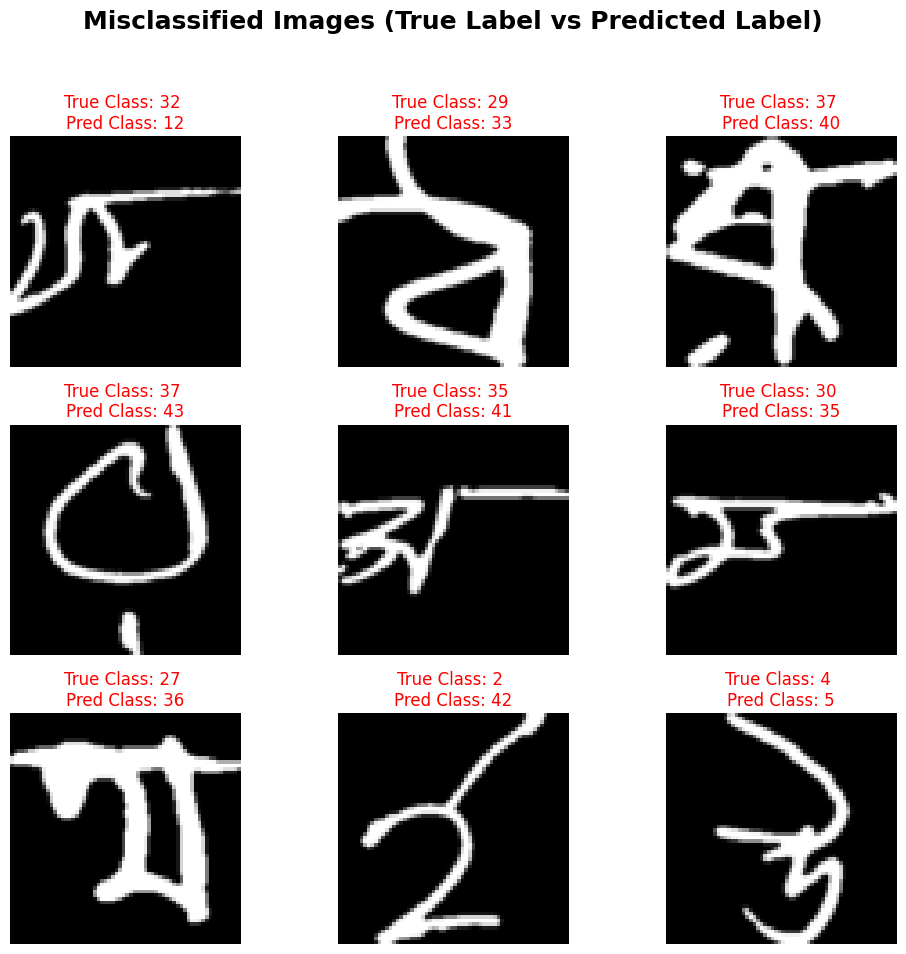

In [34]:
# Find indices where prediction does not match actual label
misclassified_idx = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10, 10))
plt.suptitle("Misclassified Images (True Label vs Predicted Label)", fontsize=18, fontweight='bold')

# Show the first 9 misclassified images
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3, 3, i + 1)
    # Ensure image size dynamically matches your current data
    plt.imshow(X_test[idx].reshape(img_size, img_size), cmap='gray')
    plt.title(f"True Class: {y_test[idx]} \nPred Class: {y_pred[idx]}", color='red', fontsize=12)
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("misclassified_gallery.png", dpi=300)
plt.show()

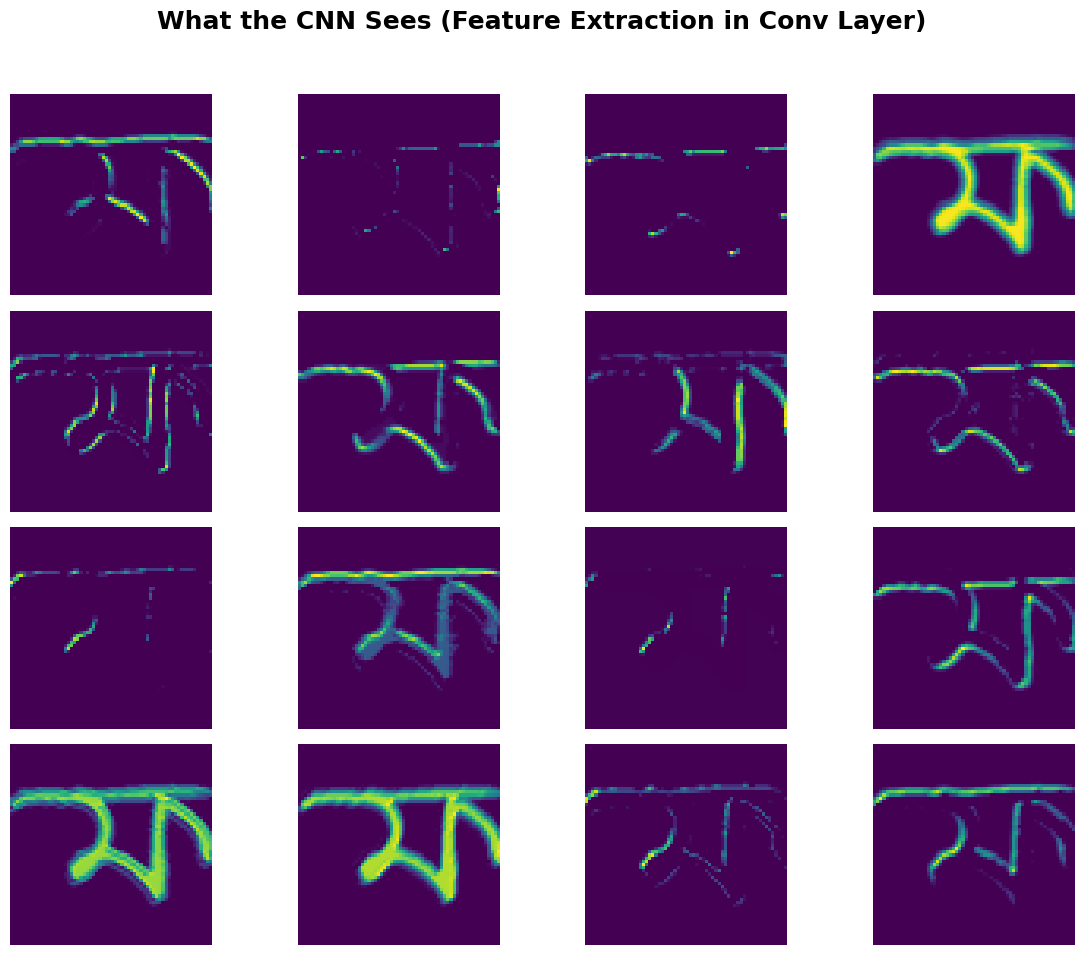

In [36]:
from tensorflow.keras import models
import matplotlib.pyplot as plt

# Safe bypass: Create a smaller model using just the first 4 layers (up to Conv2D)
activation_model = models.Sequential(model.layers[:4])

# Pass a single image through the sub-model
test_img = X_test[0].reshape(1, img_size, img_size, 1)
# 1/1 step hide korar jonno verbose=0
first_layer_activation = activation_model.predict(test_img, verbose=0)

plt.figure(figsize=(12, 10))
plt.suptitle("What the CNN Sees (Feature Extraction in Conv Layer)", fontsize=18, fontweight='bold')

# Plot the first 16 filters from the conv layer
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("feature_maps.png", dpi=300)
plt.show()

Grabbing MLP history for plot...


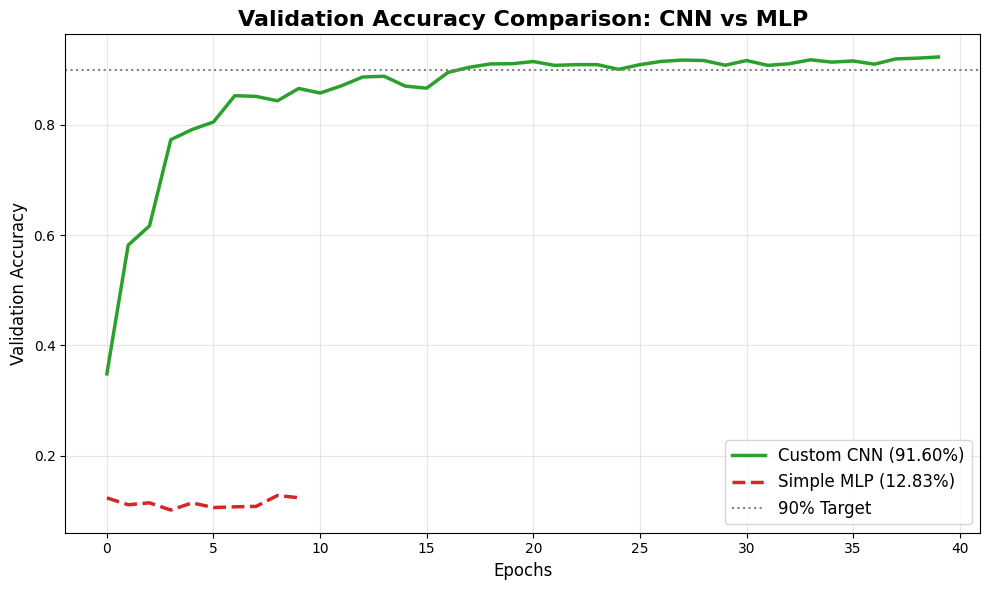

In [37]:
import matplotlib.pyplot as plt

# Get MLP history for comparison (fast 10-epoch run)
print("Grabbing MLP history for plot...")
mlp_hist = mlp.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=128, verbose=0)

plt.figure(figsize=(10, 6))
# Plot CNN validation accuracy
plt.plot(hist.history['val_accuracy'], label='Custom CNN (91.60%)', color='#2ca02c', linewidth=2.5)
# Plot MLP validation accuracy
plt.plot(mlp_hist.history['val_accuracy'], label='Simple MLP (12.83%)', color='#d62728', linewidth=2.5, linestyle='--')

plt.title('Validation Accuracy Comparison: CNN vs MLP', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.axhline(y=0.90, color='gray', linestyle=':', label='90% Target')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cnn_vs_mlp_curve.png", dpi=300)
plt.show()

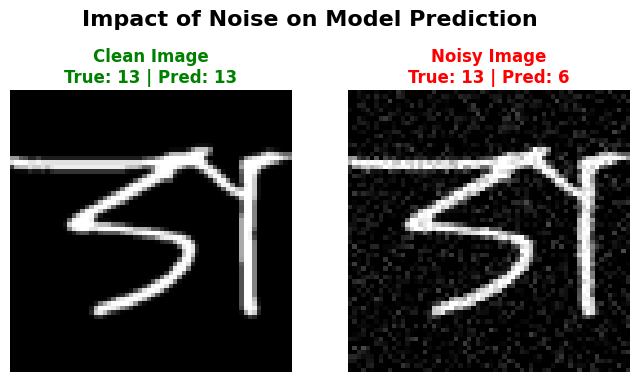

In [38]:
# Select a random test image
idx = 100
clean_img = X_test[idx]
noisy_img = add_noise(np.expand_dims(clean_img, 0))[0]

# Get predictions
clean_pred = np.argmax(model.predict(np.expand_dims(clean_img, 0), verbose=0))
noisy_pred = np.argmax(model.predict(np.expand_dims(noisy_img, 0), verbose=0))
true_label = y_test[idx]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Clean Image
axes[0].imshow(clean_img.squeeze(), cmap='gray')
clean_color = 'green' if true_label == clean_pred else 'red'
axes[0].set_title(f"Clean Image\nTrue: {true_label} | Pred: {clean_pred}", color=clean_color, fontweight='bold')
axes[0].axis('off')

# Noisy Image
axes[1].imshow(noisy_img.squeeze(), cmap='gray')
noisy_color = 'green' if true_label == noisy_pred else 'red'
axes[1].set_title(f"Noisy Image\nTrue: {true_label} | Pred: {noisy_pred}", color=noisy_color, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Impact of Noise on Model Prediction", fontsize=16, fontweight='bold', y=1.05)
plt.savefig("clean_vs_noisy.png", dpi=300, bbox_inches='tight')
plt.show()

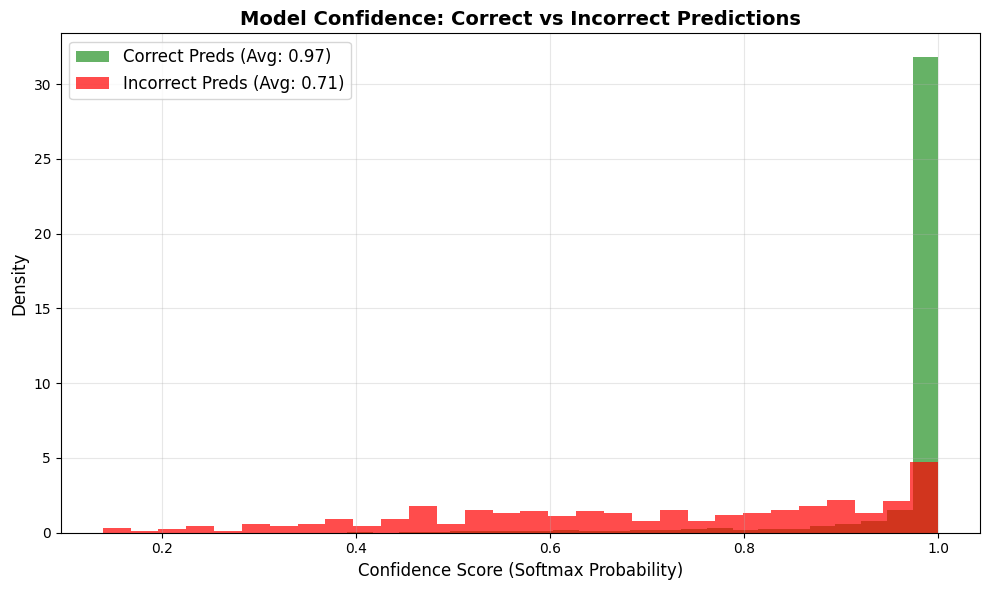

In [39]:
y_pred_probs = model.predict(X_test, verbose=0)
confidences = np.max(y_pred_probs, axis=1)

correct_conf = confidences[y_pred == y_test]
incorrect_conf = confidences[y_pred != y_test]

plt.figure(figsize=(10, 6))
plt.hist(correct_conf, bins=30, alpha=0.6, color='green', label=f'Correct Preds (Avg: {np.mean(correct_conf):.2f})', density=True)
plt.hist(incorrect_conf, bins=30, alpha=0.7, color='red', label=f'Incorrect Preds (Avg: {np.mean(incorrect_conf):.2f})', density=True)

plt.title('Model Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Score (Softmax Probability)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_histogram.png", dpi=300)
plt.show()

In [40]:
from sklearn.metrics import precision_recall_fscore_support
from IPython.display import display

# Get MLP predictions
mlp_pred = np.argmax(mlp.predict(X_test, verbose=0), axis=1)

# Calculate Macro metrics for CNN and MLP
cnn_p, cnn_r, cnn_f, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
mlp_p, mlp_r, mlp_f, _ = precision_recall_fscore_support(y_test, mlp_pred, average='macro', zero_division=0)

# Create data dictionary
table_data = {
    "Evaluation Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Robustness (Noisy Acc)",
        "Total Parameters"
    ],
    "Custom CNN": [
        f"{test_acc*100:.2f}%",
        f"{cnn_p:.4f}",
        f"{cnn_r:.4f}",
        f"{cnn_f:.4f}",
        f"{noisy_acc*100:.2f}%",
        f"{model.count_params():,}"
    ],
    "Simple MLP Baseline": [
        f"{mlp_acc*100:.2f}%",
        f"{mlp_p:.4f}",
        f"{mlp_r:.4f}",
        f"{mlp_f:.4f}",
        "N/A (Skipped)",
        f"{mlp.count_params():,}"
    ]
}

# Display as a styled pandas dataframe
df_comp = pd.DataFrame(table_data)
df_styled = df_comp.style.set_properties(**{'text-align': 'center', 'border': '1px solid black'})\
                     .set_table_styles([dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2'), ('font-size', '14px')])])\
                     .hide(axis="index")

print("\n--- DETAILED MODEL COMPARISON ---")
display(df_styled)


--- DETAILED MODEL COMPARISON ---


Evaluation Metric,Custom CNN,Simple MLP Baseline
Test Accuracy,91.60%,12.83%
Macro Precision,0.9178,0.1997
Macro Recall,0.9160,0.1301
Macro F1-Score,0.9160,0.1207
Robustness (Noisy Acc),13.23%,N/A (Skipped)
Total Parameters,"2,513,074","2,241,842"
